# Quinta Playa — Shorelines Post-Processing

### Imports and data loading

In [31]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from scipy import stats

data = os.path.join('..', 'data', 'shorelines')

filepath = os.path.join('..', 'output')

# transects (the shortened ones that the time series refer to)
tr = gpd.read_file(os.path.join(data, 'quinta_playa_transects_short.geojson'))
transects = {row['name']: np.array(row.geometry.coords) for _, row in tr.iterrows()}

# mapped shorelines (one line per image)
shorelines = gpd.read_file(os.path.join(data, 'QUINTA_shorelines.geojson'))
shorelines = shorelines.set_crs(epsg=32715, allow_override=True)   # coords are already UTM 15S
shorelines['date'] = pd.to_datetime(shorelines['date'])
shorelines['geoaccuracy'] = pd.to_numeric(shorelines['geoaccuracy'], errors='coerce')

# per-image metadata (satellite, Otsu threshold, cloud cover, georef accuracy)
meta = pd.read_csv(os.path.join(data, 'QUINTA_shoreline_metadata.csv'))
meta['dates'] = pd.to_datetime(meta['dates'], utc=True).dt.tz_localize(None)

# tidally corrected + despiked cross-shore time series
df = pd.read_csv(os.path.join(data, 'transect_time_series_tidally_corrected_despiked.csv'))
df['dates'] = pd.to_datetime(df['dates'], utc=True).dt.tz_localize(None)
dates = list(df['dates'])
cross_distance = {key: df[key].to_numpy() for key in transects if key in df.columns}

print(f"{len(dates)} dates, {len(cross_distance)} transects: {list(cross_distance)}")

395 dates, 10 transects: ['B6', 'C2', 'C1', 'B4', 'B5', 'A1', 'A2', 'B1', 'B2', 'B3']


### Map of shorelines and transects

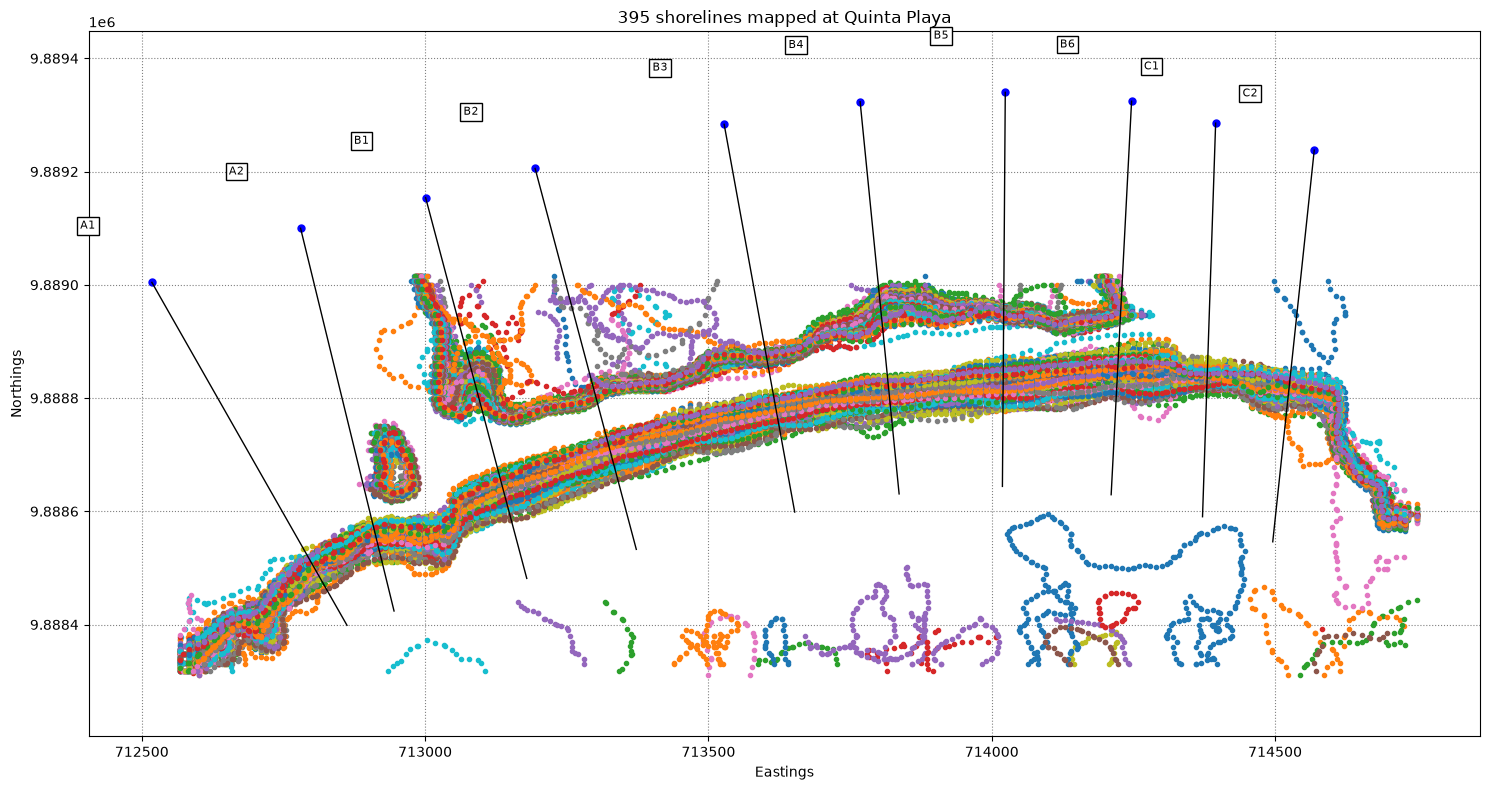

In [34]:
from shapely import get_coordinates

maps = os.path.join('..', 'output', 'maps')
os.makedirs(maps, exist_ok=True)


fig = plt.figure(figsize=[15, 8], tight_layout=True)
plt.axis('equal')
plt.xlabel('Eastings')
plt.ylabel('Northings')
plt.grid(linestyle=':', color='0.5')

for date, grp in shorelines.groupby('date'):
    xy = get_coordinates(grp.geometry)        # works for Point, MultiPoint or LineString
    plt.plot(xy[:, 0], xy[:, 1], '.', label=date.strftime('%d-%m-%Y'))
plt.title(f'{shorelines["date"].nunique()} shorelines mapped at Quinta Playa')

for key, xy in transects.items():
    plt.plot(xy[0, 0], xy[0, 1], 'bo', ms=5)
    plt.plot(xy[:, 0], xy[:, 1], 'k-', lw=1)
    plt.text(xy[0, 0] - 100, xy[0, 1] + 100, key,
             va='center', ha='right', fontsize=8,
             bbox=dict(boxstyle="square", ec='k', fc='w'))

fig.savefig(os.path.join(maps, 'QUINTA_shorelines_and_transects.png'), dpi=300)

## Initial Analysis

### Averaging and trend functions

Re-implementations of `seasonal_average`, `monthly_average` and `calculate_trend` from CoastSat `SDS_transects.py` (Vos et al., 2019), using the same season definitions and labelling conventions so results are comparable.

In [23]:
DAYS_IN_YEAR = 365.2425

def seasonal_average(dates, chainages):
    s = pd.Series(np.asarray(chainages), index=pd.DatetimeIndex(dates)).dropna()
    yr, mo = s.index.year, s.index.month
    labels = {1: 'DJF', 4: 'MAM', 7: 'JJA', 10: 'SON'}
    dict_seas = {lab: {'dates': [], 'chainages': []} for lab in labels.values()}
    dates_seas, chain_seas, season_ts = [], [], []
    for year in np.unique(yr):
        for m, lab in labels.items():
            if m == 1:   # Dec of previous year + Jan + Feb
                mask = ((yr == year - 1) & (mo == 12)) | ((yr == year) & (mo <= 2))
            else:
                mask = (yr == year) & (mo >= m - 1) & (mo <= m + 1)
            if not mask.any():
                continue
            val = s[mask].mean()
            d = datetime(year, m, 1)
            dict_seas[lab]['dates'].append(d)
            dict_seas[lab]['chainages'].append(val)
            dates_seas.append(d); chain_seas.append(val); season_ts.append(m)
    for lab in dict_seas:
        dict_seas[lab]['chainages'] = np.array(dict_seas[lab]['chainages'])
    return dict_seas, dates_seas, np.array(chain_seas), np.array(season_ts)


def monthly_average(dates, chainages):
    s = pd.Series(np.asarray(chainages), index=pd.DatetimeIndex(dates)).dropna()
    yr, mo = s.index.year, s.index.month
    names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
    dict_month = {n: {'dates': [], 'chainages': []} for n in names}
    dates_m, chain_m, month_ts = [], [], []
    last = s.index[-1]
    for year in np.unique(yr):
        for m in range(1, 13):
            d = datetime(year, m, 15)
            if d > last - timedelta(days=30):
                break
            mask = (yr == year) & (mo == m)
            if not mask.any():
                continue
            val = s[mask].mean()
            dict_month[names[m-1]]['dates'].append(d)
            dict_month[names[m-1]]['chainages'].append(val)
            dates_m.append(d); chain_m.append(val); month_ts.append(m)
    for n in dict_month:
        dict_month[n]['chainages'] = np.array(dict_month[n]['chainages'])
    return dict_month, dates_m, np.array(chain_m), np.array(month_ts)


def calculate_trend(dates, chainage):
    """Linear trend in m/year. Returns (trend, fitted_line, pvalue, r2)."""
    t = np.array([d.toordinal() for d in dates], dtype=float)
    t = (t - t.min()) / DAYS_IN_YEAR
    res = stats.linregress(t, chainage)
    return res.slope, t * res.slope + res.intercept, res.pvalue, res.rvalue**2

### Seasonal averages and long-term trend per transect

,trend_m_per_yr,pvalue,r2
B6,-0.397,0.024,0.055
C2,-0.126,0.286,0.012
C1,-0.037,0.651,0.002
B4,-0.317,0.004,0.088
B5,-0.331,0.028,0.053
A1,0.164,0.077,0.034
A2,0.054,0.632,0.003
B1,-0.200,0.157,0.022
B2,-0.312,0.007,0.076
B3,-0.236,0.022,0.056


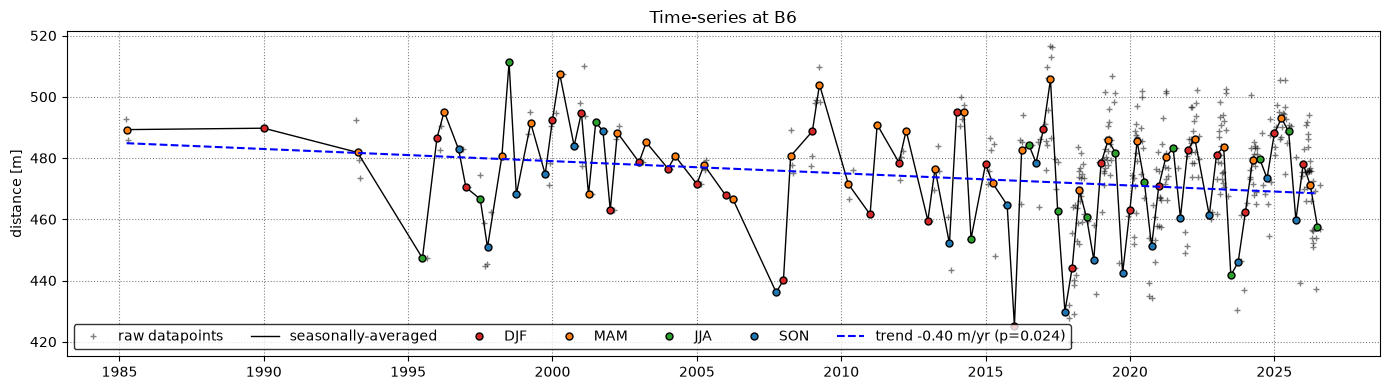

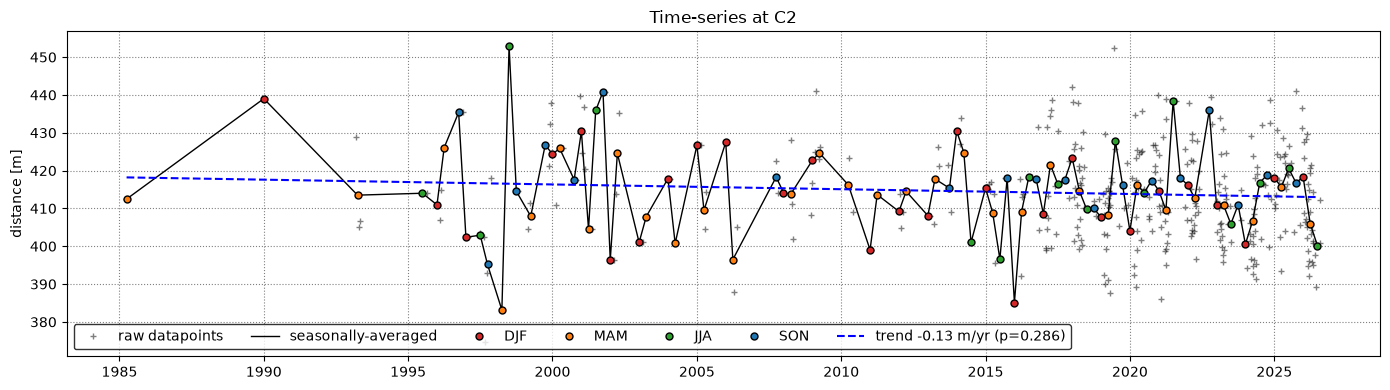

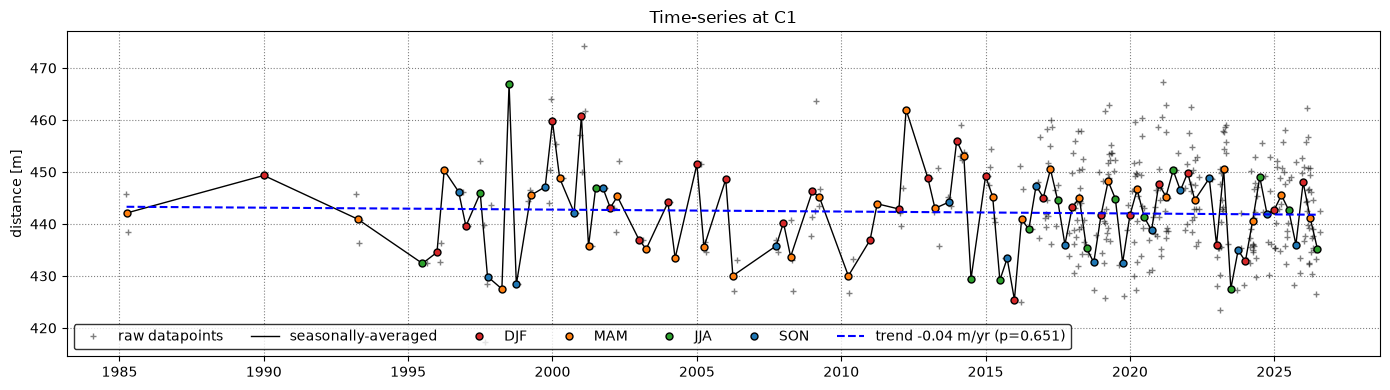

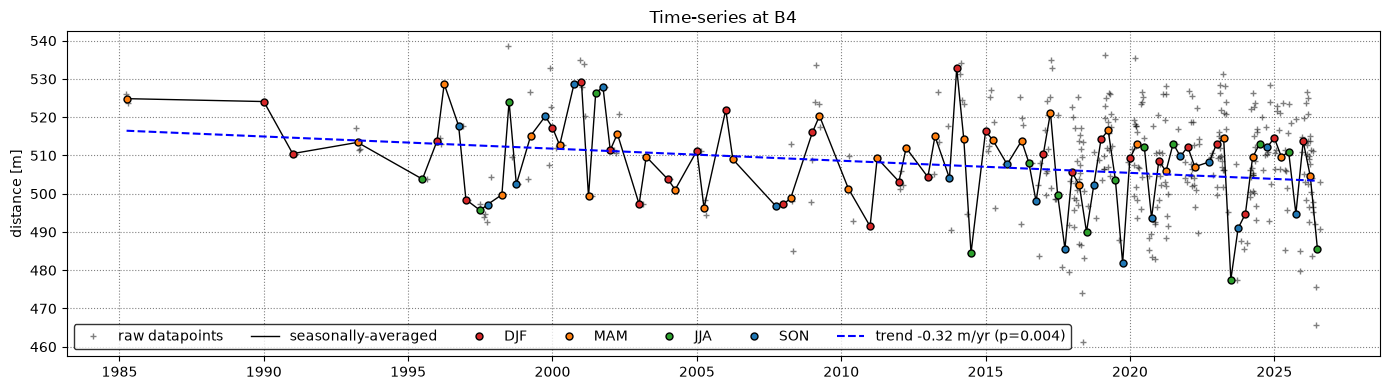

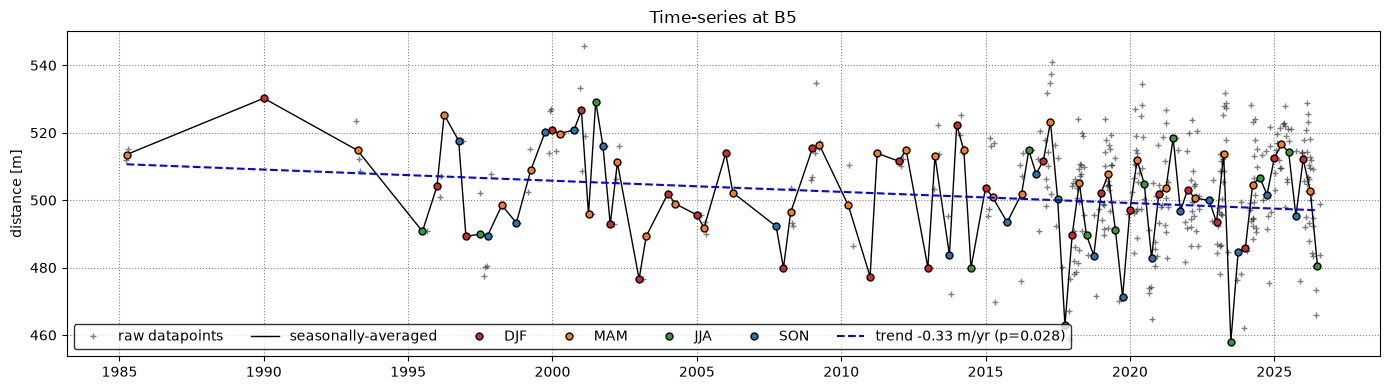

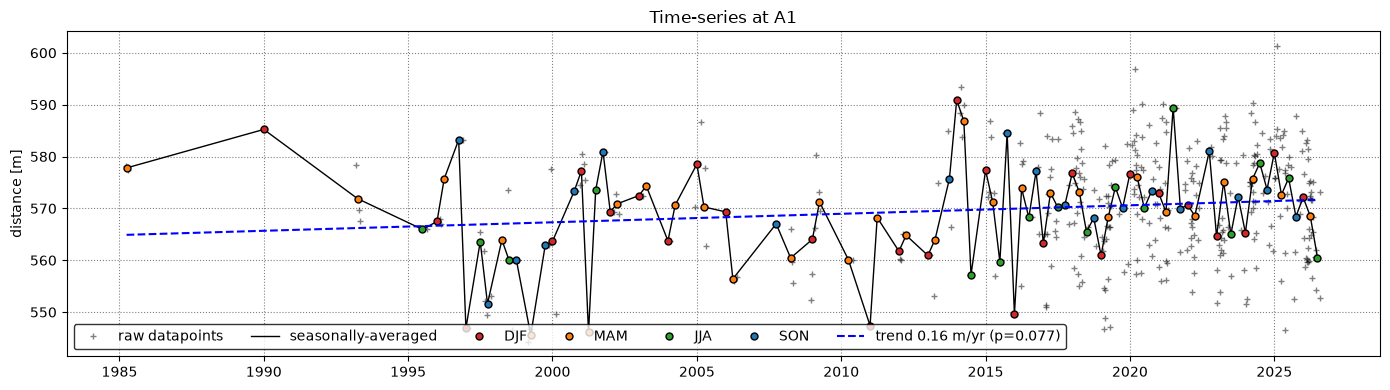

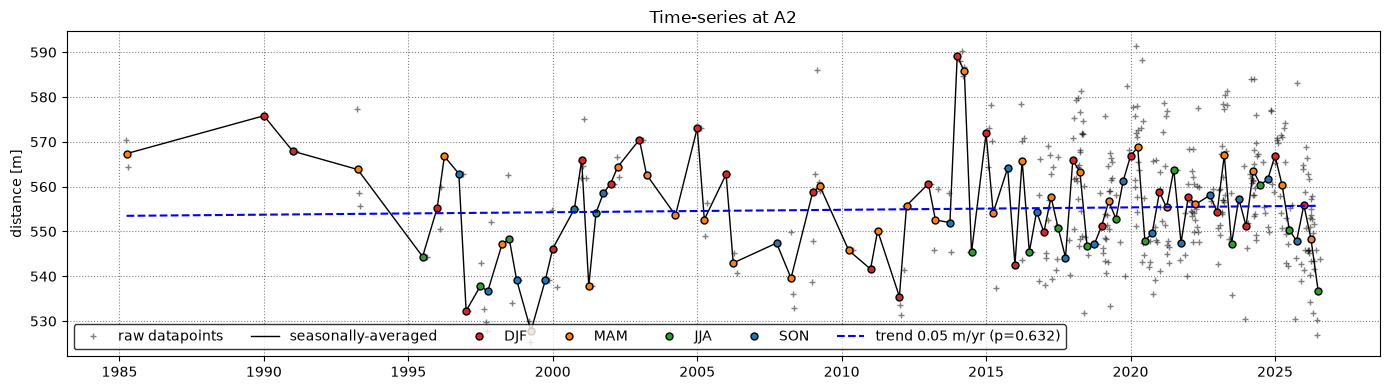

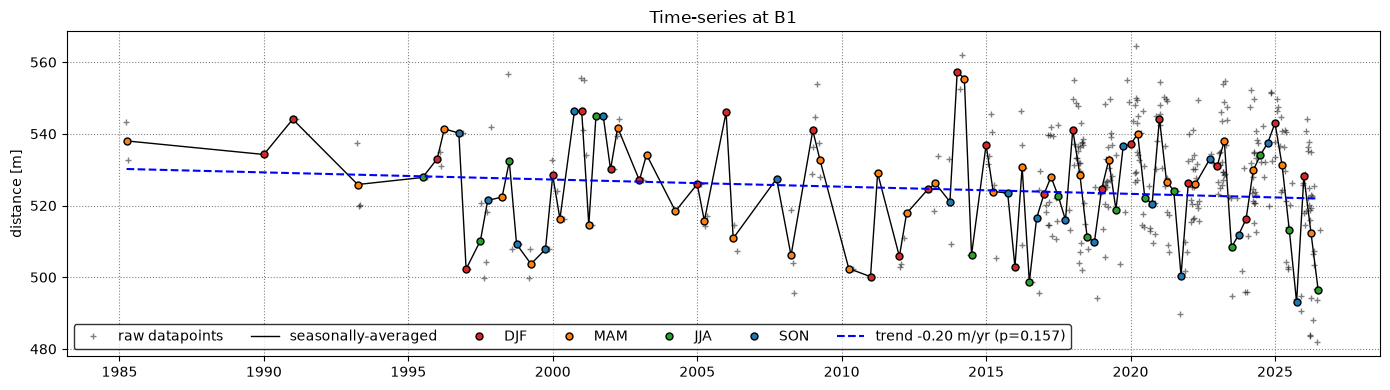

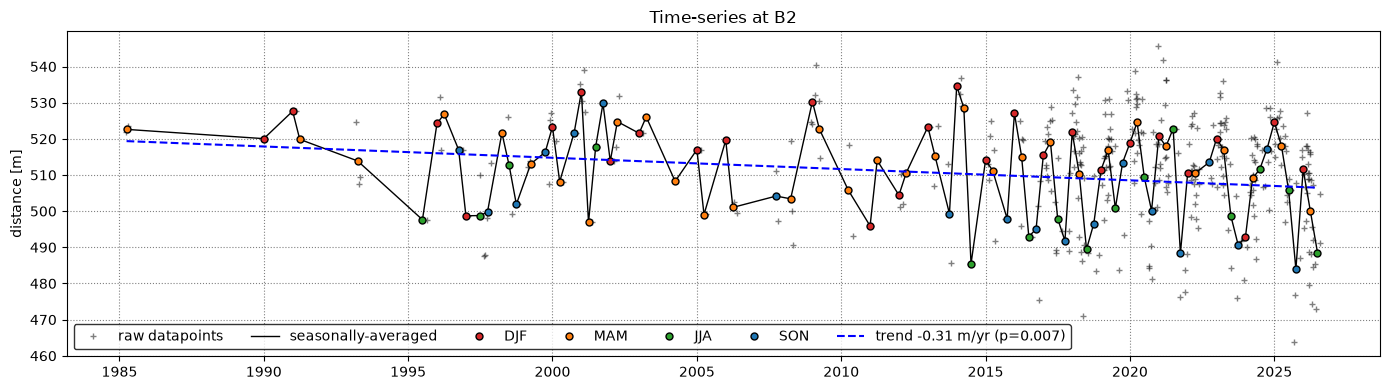

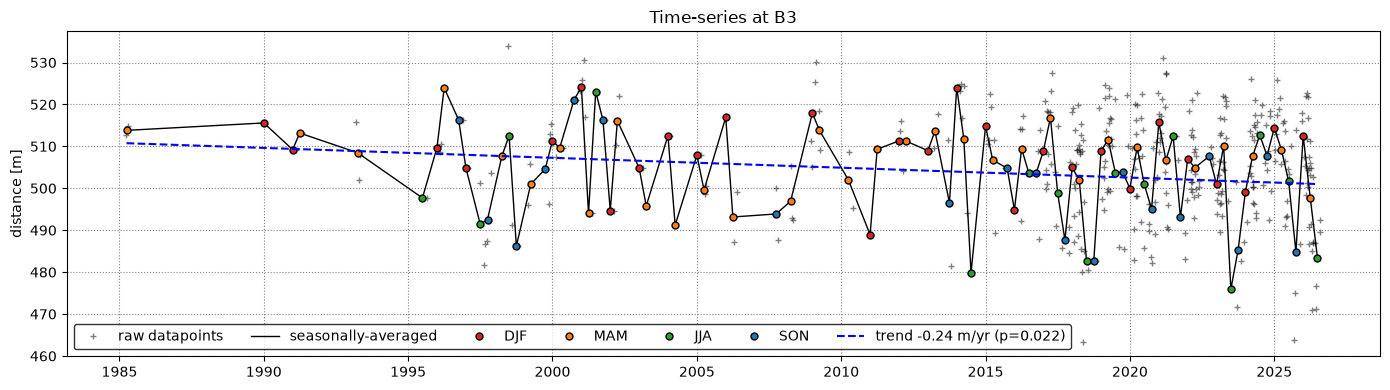

In [36]:
fp_seasonal = os.path.join(filepath,'seasonal_timeseries')
os.makedirs(fp_seasonal, exist_ok=True)

season_colors = {'DJF': 'C3', 'MAM': 'C1', 'JJA': 'C2', 'SON': 'C0'}
trends = {}
for key, chainage in cross_distance.items():
    ok = ~np.isnan(chainage)
    d_ok = [dates[i] for i in np.where(ok)[0]]
    c_ok = chainage[ok]

    dict_seas, dates_seas, chain_seas, _ = seasonal_average(d_ok, c_ok)
    trend, y, p, r2 = calculate_trend(dates_seas, chain_seas)
    trends[key] = {'trend_m_per_yr': trend, 'pvalue': p, 'r2': r2}

    fig, ax = plt.subplots(figsize=[14, 4], tight_layout=True)
    ax.grid(linestyle=':', color='0.5')
    ax.plot(d_ok, c_ok, '+', color='k', ms=4, alpha=0.5, label='raw datapoints')
    ax.plot(dates_seas, chain_seas, '-', lw=1, color='k', label='seasonally-averaged')
    for seas, v in dict_seas.items():
        ax.plot(v['dates'], v['chainages'], 'o', mec='k', color=season_colors[seas], ms=5, label=seas)
    ax.plot(dates_seas, y, '--', color='b', label=f'trend {trend:.2f} m/yr (p={p:.3f})')
    ax.set(ylabel='distance [m]', title=f'Time-series at {key}')
    ax.legend(loc='lower left', ncol=7, frameon=True, edgecolor='k')
    fig.savefig(os.path.join(fp_seasonal,  f'{key}_seasonal_time_series.png'), dpi=300)

pd.DataFrame(trends).T.round(3)

### Monthly averages per transect

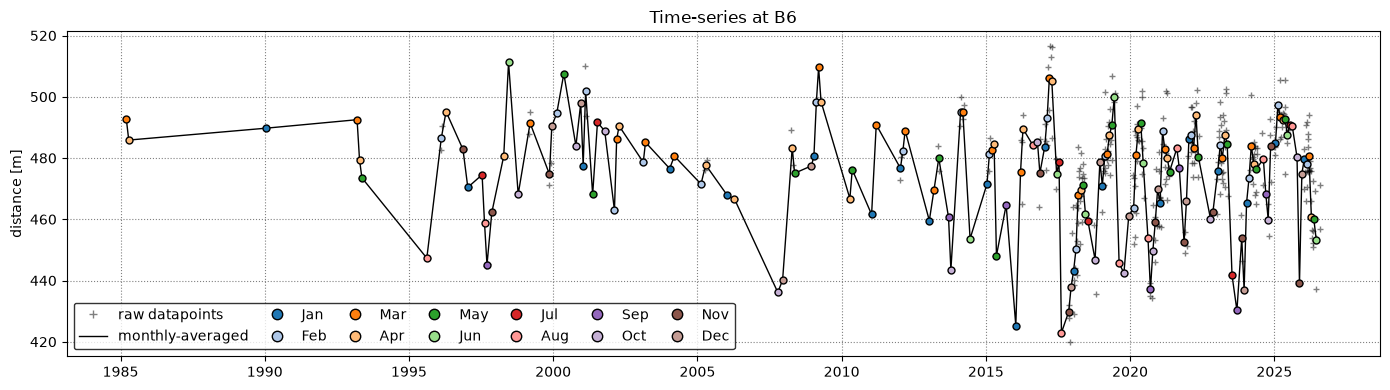

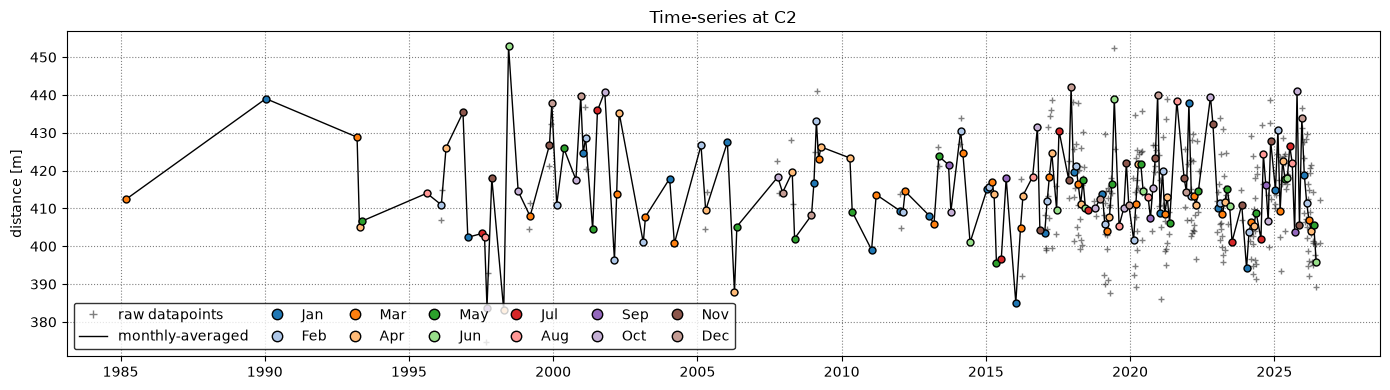

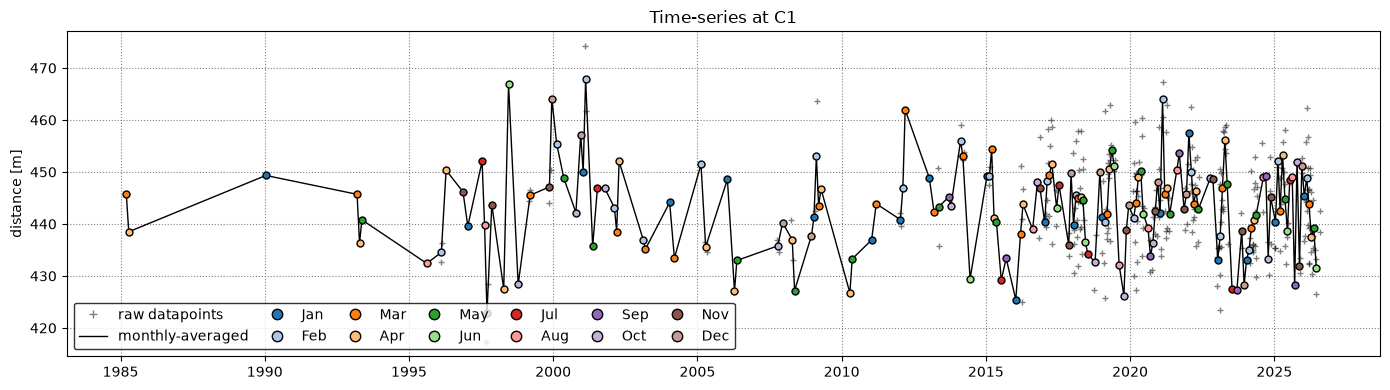

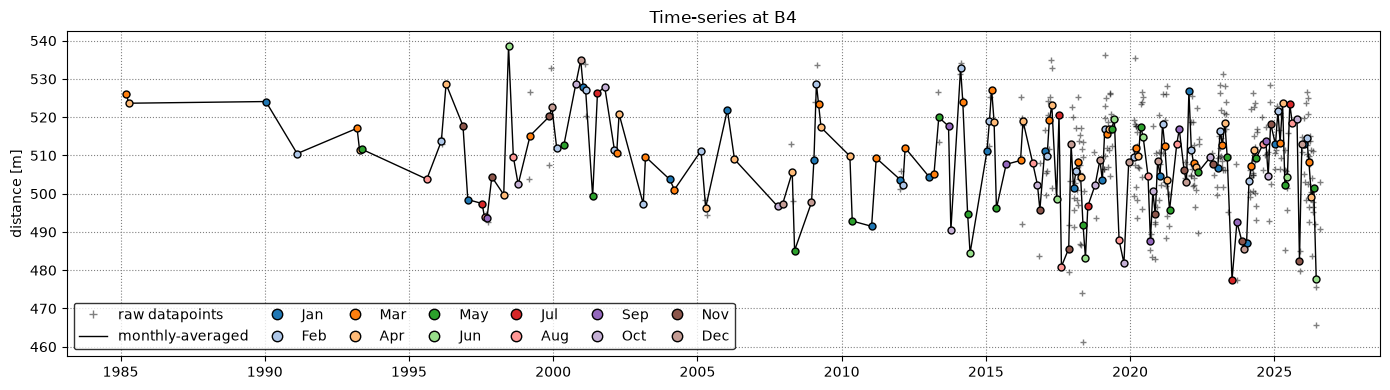

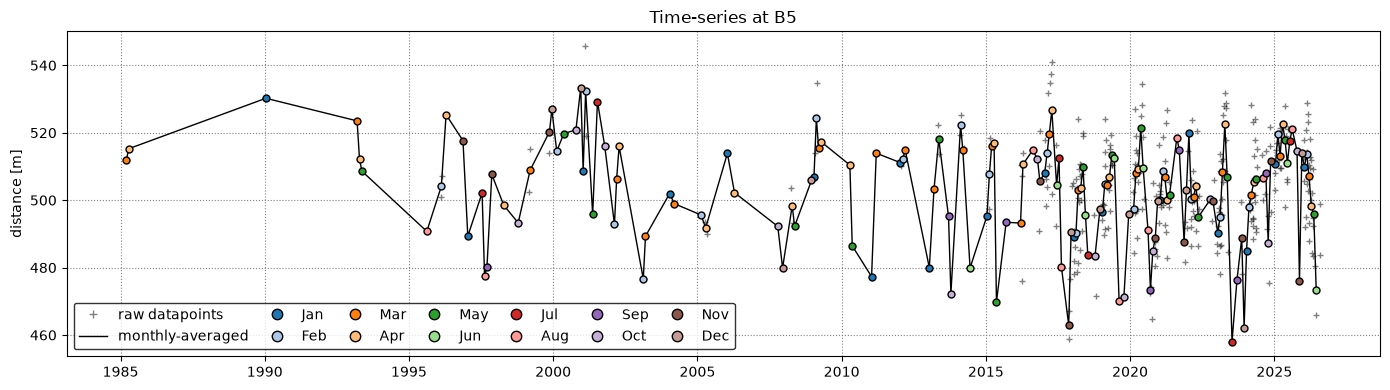

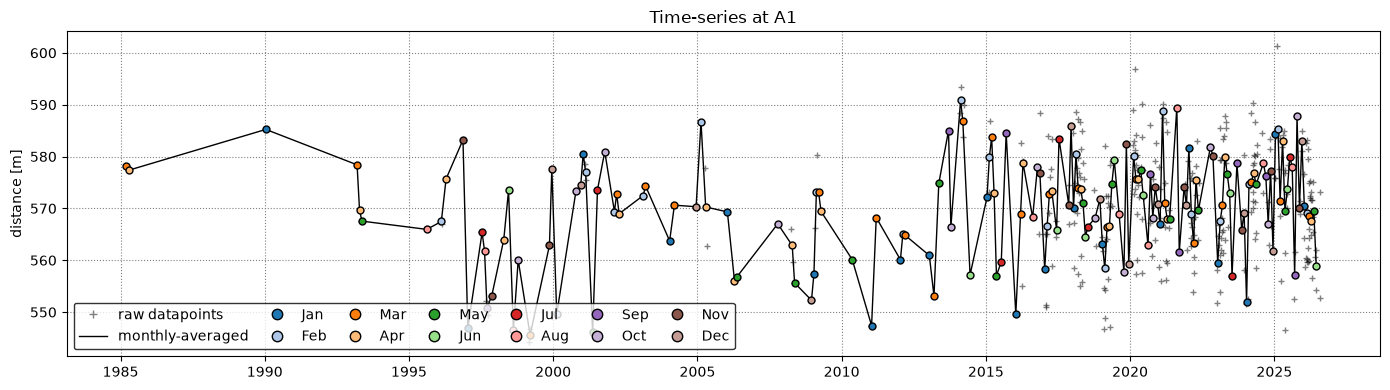

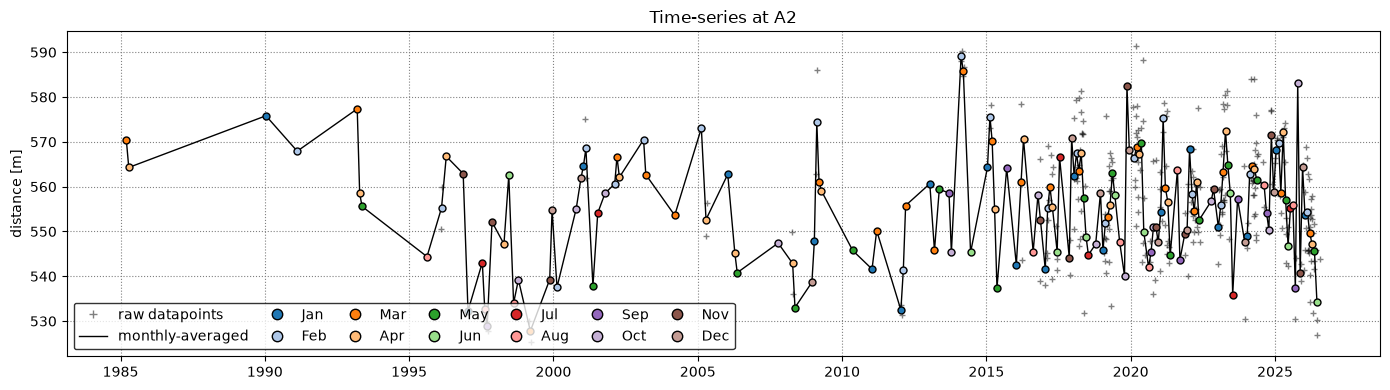

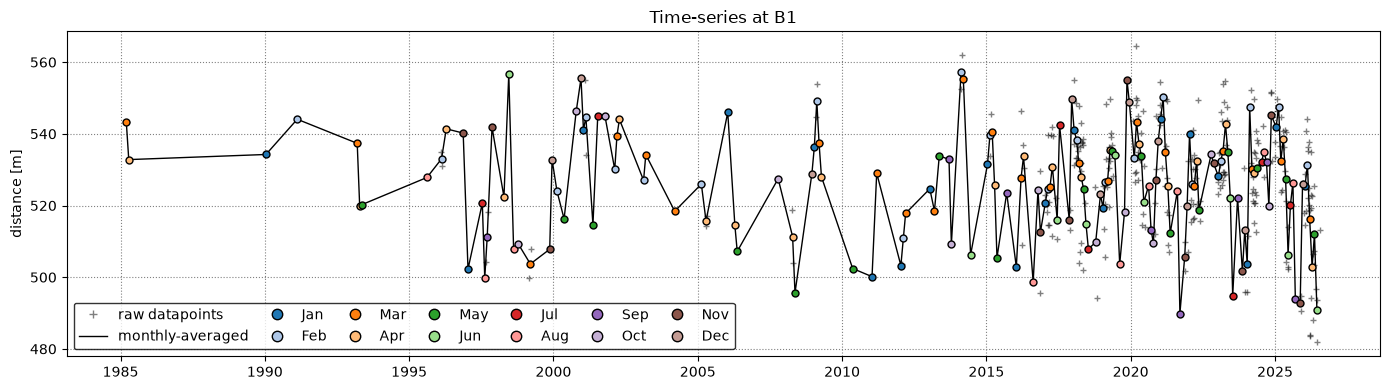

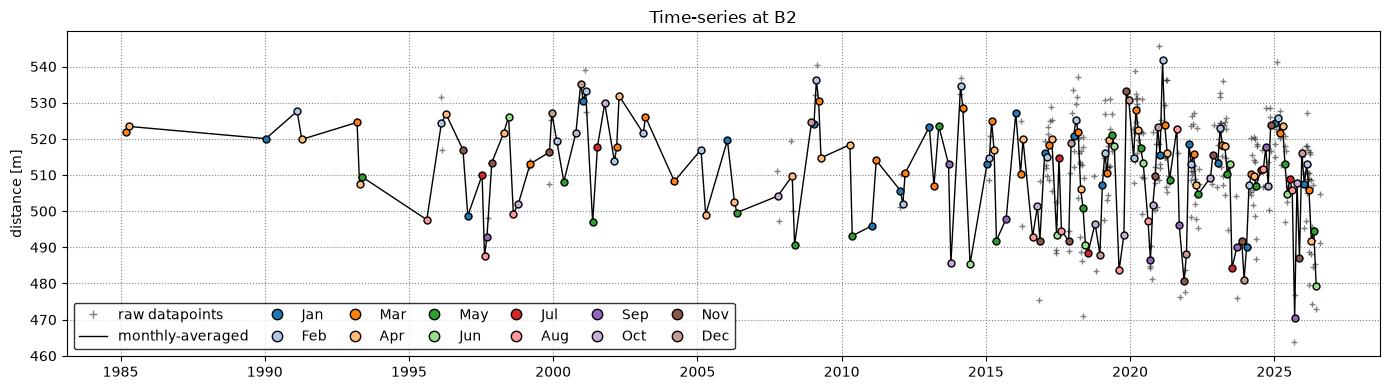

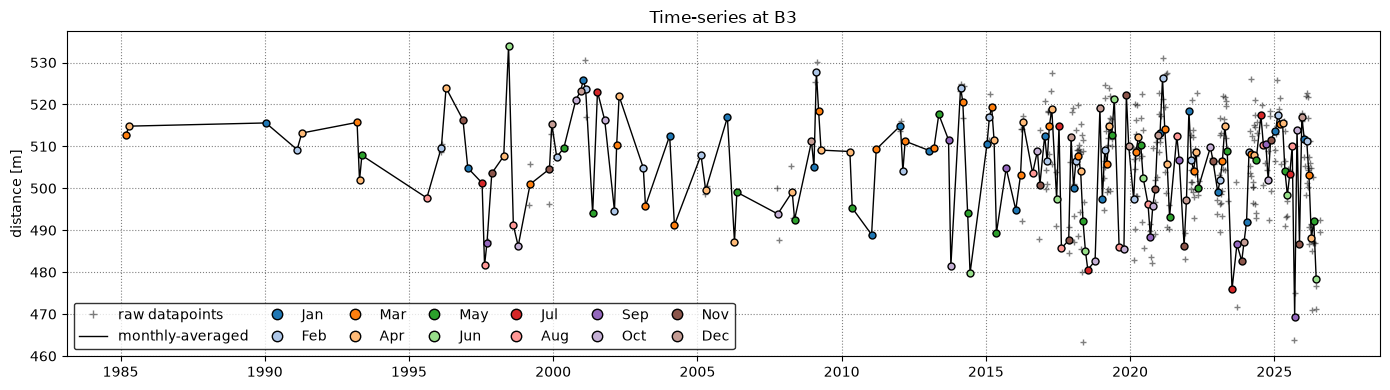

In [35]:
fp_monthly = os.path.join(filepath,'monthly_timeseries')
os.makedirs(fp_monthly, exist_ok=True)

month_colors = plt.get_cmap('tab20')
for key, chainage in cross_distance.items():
    ok = ~np.isnan(chainage)
    d_ok = [dates[i] for i in np.where(ok)[0]]
    c_ok = chainage[ok]

    dict_month, dates_m, chain_m, _ = monthly_average(d_ok, c_ok)

    fig, ax = plt.subplots(figsize=[14, 4], tight_layout=True)
    ax.grid(linestyle=':', color='0.5')
    ax.plot(d_ok, c_ok, '+', color='k', ms=4, alpha=0.5, label='raw datapoints')
    ax.plot(dates_m, chain_m, '-', lw=1, color='k', label='monthly-averaged')
    for k, (month, v) in enumerate(dict_month.items()):
        ax.plot(v['dates'], v['chainages'], 'o', mec='k', color=month_colors(k), ms=5, label=month)
    ax.set(ylabel='distance [m]', title=f'Time-series at {key}')
    ax.legend(loc='lower left', ncol=7, markerscale=1.5, frameon=True, edgecolor='k', columnspacing=1)
    plt.show()
    fig.savefig(os.path.join(fp_monthly,  f'{key}_monthly_time_series.png'), dpi=300)

### Seasonal Excursion 

In [37]:
# ---- 1. Monthly averages into one long dataframe ----
rows = []
for key, chainage in cross_distance.items():
    ok = ~np.isnan(chainage)
    d_ok = [dates[i] for i in np.where(ok)[0]]
    _, dates_m, chain_m, month_ts = monthly_average(d_ok, chainage[ok])
    for d, c, m in zip(dates_m, chain_m, month_ts):
        rows.append({'transect': key, 'date': d, 'year': d.year, 'month': m, 'chainage': c})

df_monthly = pd.DataFrame(rows)

# excursion = monthly value minus that transect's long-term mean, so transects are comparable
df_monthly['excursion'] = df_monthly['chainage'] - df_monthly.groupby('transect')['chainage'].transform('mean')
df_monthly.head()

,transect,date,year,month,chainage,excursion
0,B6,1985-03-15,1985,3,492.692263,18.173893
1,B6,1985-04-15,1985,4,485.858623,11.340253
2,B6,1990-01-15,1990,1,489.734754,15.216385
3,B6,1993-03-15,1993,3,492.511424,17.993054
4,B6,1993-04-15,1993,4,479.444107,4.925738


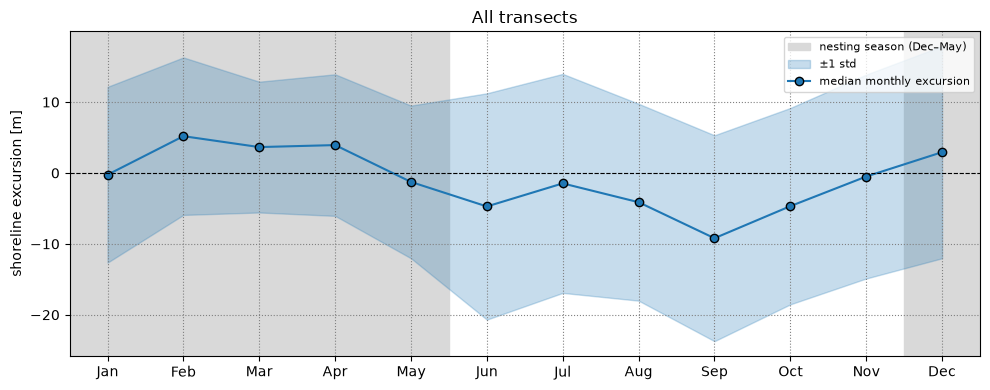

In [38]:
# ---- 2. Median monthly excursion with ±1 std band ----
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

def plot_monthly_excursion(df, transect=None, ax=None):
    d = df if transect is None else df[df['transect'] == transect]
    stats_m = d.groupby('month')['excursion'].agg(['median', 'std', 'count']).reindex(range(1, 13))

    if ax is None:
        fig, ax = plt.subplots(figsize=[10, 4], tight_layout=True)
    x = stats_m.index.to_numpy()

    # nesting season Dec–May
    ax.axvspan(0.5, 5.5, color='0.85', zorder=0, label='nesting season (Dec–May)')
    ax.axvspan(11.5, 12.5, color='0.85', zorder=0)

    ax.fill_between(x, stats_m['median'] - stats_m['std'], stats_m['median'] + stats_m['std'],
                    color='C0', alpha=0.25, label='±1 std')
    ax.plot(x, stats_m['median'], 'o-', color='C0', mec='k', label='median monthly excursion')
    ax.axhline(0, color='k', lw=0.8, ls='--')

    ax.set(xticks=x, xticklabels=month_names, xlim=(0.5, 12.5),
           ylabel='shoreline excursion [m]',
           title='All transects' if transect is None else f'Transect {transect}')
    ax.grid(linestyle=':', color='0.5')
    ax.legend(loc='upper right', fontsize=8)
    return stats_m

# all transects pooled
stats_all = plot_monthly_excursion(df_monthly)

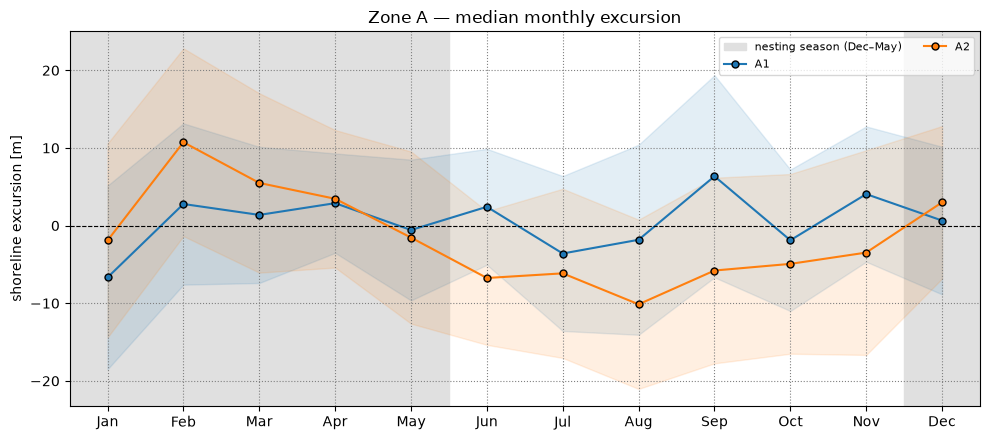

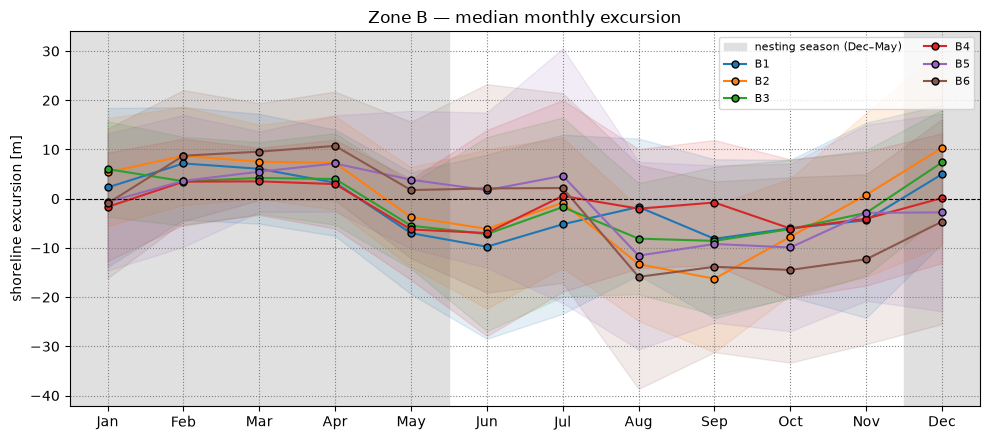

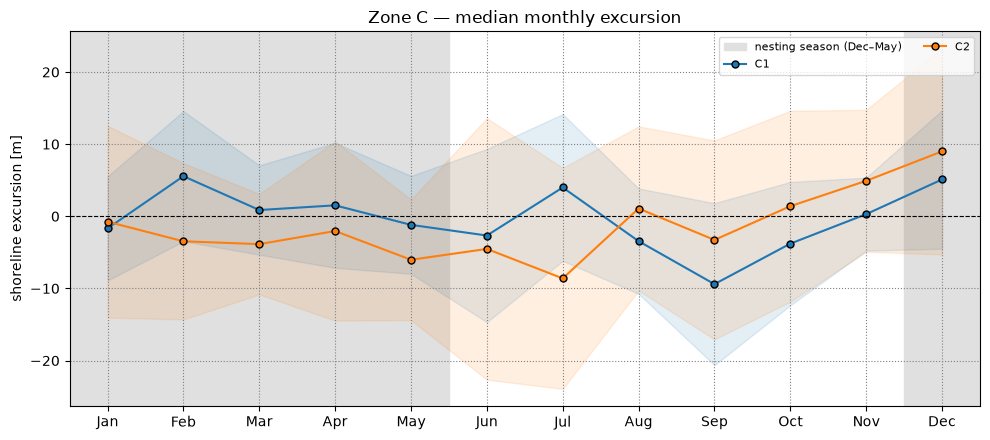

In [40]:
# colours per transect — edit freely
transect_colors = {
    'A1': '#1f77b4', 'A2': '#ff7f0e',
    'B1': '#1f77b4', 'B2': '#ff7f0e', 'B3': '#2ca02c', 'B4': '#d62728', 'B5': '#9467bd', 'B6': '#8c564b',
    'C1': '#1f77b4', 'C2': '#ff7f0e',
}

def plot_zone_excursion(df, zone, colors=transect_colors, show_std=True, ax=None):
    keys = sorted(k for k in df['transect'].unique() if k.startswith(zone))
    if ax is None:
        fig, ax = plt.subplots(figsize=[10, 4.5], tight_layout=True)
    x = np.arange(1, 13)

    # nesting season Dec–May
    ax.axvspan(0.5, 5.5, color='0.88', zorder=0, label='nesting season (Dec–May)')
    ax.axvspan(11.5, 12.5, color='0.88', zorder=0)

    for key in keys:
        s = df[df['transect'] == key].groupby('month')['excursion'].agg(['median', 'std']).reindex(x)
        c = colors.get(key, 'k')
        if show_std:
            ax.fill_between(x, s['median'] - s['std'], s['median'] + s['std'], color=c, alpha=0.12)
        ax.plot(x, s['median'], 'o-', color=c, mec='k', ms=5, label=key)

    ax.axhline(0, color='k', lw=0.8, ls='--')
    ax.set(xticks=x, xticklabels=month_names, xlim=(0.5, 12.5),
           ylabel='shoreline excursion [m]', title=f'Zone {zone} — median monthly excursion')
    ax.grid(linestyle=':', color='0.5')
    ax.legend(loc='upper right', fontsize=8, ncol=2)
    return ax

for zone in ['A', 'B', 'C']:
    plot_zone_excursion(df_monthly, zone)

In [41]:
## Calculate the time bewteen data points for each transect

# ---- gaps between consecutive valid data points, per transect ----

rows = []
for key, chainage in cross_distance.items():
    ok = ~np.isnan(chainage)
    d_ok = pd.DatetimeIndex([dates[i] for i in np.where(ok)[0]])
    gaps = np.diff(d_ok).astype('timedelta64[D]').astype(float)   # days
    for d, g in zip(d_ok[1:], gaps):
        rows.append({'transect': key, 'date': d, 'gap_days': g})

df_gaps = pd.DataFrame(rows)

gap_stats = (df_gaps.groupby('transect')['gap_days']
             .agg(n_points=lambda g: len(g) + 1, median='median', mean='mean', p90=lambda g: g.quantile(0.9), max='max')
             .round(1))
gap_stats

,n_points,median,mean,p90,max
transect,,,,,
A1,364,10.0,41.2,80.0,1727.0
A2,355,10.0,42.2,82.1,1727.0
B1,349,10.0,42.9,84.5,1727.0
B2,360,10.0,41.6,80.6,1727.0
B3,365,10.0,41.0,80.0,1727.0
B4,363,10.0,41.3,80.0,1727.0
B5,358,10.0,41.8,81.2,1727.0
B6,356,10.0,42.1,81.8,1727.0
C1,361,10.0,41.5,80.0,1727.0


## In-Depth Series Decomposition